<a href="https://colab.research.google.com/github/Priyanshu2003061/Disaster_Reporting_App/blob/main/Movie%20Recommender%20System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

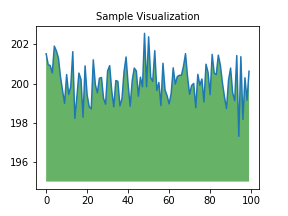

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

# Task
Create a movie recommender system that includes data loading, preprocessing, model implementation, recommendation generation, and evaluation.

## Load Movie Data

### Subtask:
Load a suitable movie dataset (e.g., MovieLens) into a pandas DataFrame. This will involve fetching the dataset and inspecting its structure.


**Reasoning**:
First, I'll import the pandas library to enable data manipulation using DataFrames. Then, I will download and extract the MovieLens 100k dataset. Next, I'll load the 'u.data' file into a pandas DataFrame, specifying the separator and column names as instructed. Afterward, I will display the first 5 rows to inspect the data's structure, and finally, I'll print the DataFrame's info to check data types and non-null values. This sequence will ensure the dataset is properly loaded and its initial characteristics are understood.



In [ ]:
import pandas as pd
import requests
import zipfile
import io

# Download the MovieLens 100k dataset
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('ml-100k/u.data') as f:
        # Load the 'u.data' file into a pandas DataFrame
        # The file is tab-separated and has no header
        column_names = ['user_id', 'item_id', 'rating', 'timestamp']
        df = pd.read_csv(f, sep='\t', header=None, names=column_names)

print("MovieLens dataset loaded successfully.")
print("First 5 rows of the DataFrame:")
df.head()


MovieLens dataset loaded successfully.
First 5 rows of the DataFrame:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


**Reasoning**:
The previous step successfully loaded the MovieLens dataset and displayed the first 5 rows. The next instruction in the subtask is to print the DataFrame's info to check data types and non-null values. This will provide a summary of the DataFrame's structure, including column data types and the count of non-null values.



In [ ]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


## Preprocess Data

### Subtask:
Load additional movie and user metadata, and create a user-item interaction matrix.


**Reasoning**:
First, I'll load the 'ml-100k/u.item' file into a new pandas DataFrame, assigning the specified column names. This dataframe contains movie metadata.



In [ ]:
import pandas as pd
import requests
import zipfile
import io

# Define the URL for the MovieLens 100k dataset (already downloaded in previous step, but keep for completeness)
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"

# Download and extract the MovieLens 100k dataset (already downloaded, but keep for completeness)
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('ml-100k/u.item') as f:
        # Load the 'u.item' file into a pandas DataFrame
        # The file is pipe-separated and has no header
        item_column_names = ['item_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL'] + \
                            [f'genre_{i}' for i in range(19)]
        movies_df = pd.read_csv(f, sep='|', header=None, names=item_column_names, encoding='latin-1')

print("Movie metadata loaded successfully.")
print("First 5 rows of the movies DataFrame:")
movies_df.head()

Movie metadata loaded successfully.
First 5 rows of the movies DataFrame:


,item_id,title,release_date,video_release_date,IMDb_URL,genre_0,genre_1,genre_2,genre_3,genre_4,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


**Reasoning**:
The user wants to load additional movie and user metadata and create a user-item interaction matrix. The previous step loaded the movie metadata. Now, I need to load the user metadata from 'ml-100k/u.user' into a new pandas DataFrame, assign appropriate column names, display the first 5 rows, and print its info. This aligns with the second instruction of the subtask.



In [ ]:
import pandas as pd
import requests
import zipfile
import io

# Define the URL for the MovieLens 100k dataset (already downloaded in previous step, but keep for completeness)
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"

# Download and extract the MovieLens 100k dataset (already downloaded, but keep for completeness)
response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('ml-100k/u.user') as f:
        # Load the 'u.user' file into a pandas DataFrame
        # The file is pipe-separated and has no header
        user_column_names = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
        users_df = pd.read_csv(f, sep='|', header=None, names=user_column_names)

print("User metadata loaded successfully.")
print("First 5 rows of the users DataFrame:")
users_df.head()

User metadata loaded successfully.
First 5 rows of the users DataFrame:


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


**Reasoning**:
I have already loaded `movies_df` and `users_df` and displayed their first 5 rows. Now, I will print the info for both DataFrames to inspect their structures and data types, as per the instruction.



In [ ]:
print("\nDataFrame Info for movies_df:")
movies_df.info()

print("\nDataFrame Info for users_df:")
users_df.info()


DataFrame Info for movies_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   item_id             1682 non-null   int64  
 1   title               1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   IMDb_URL            1679 non-null   object 
 5   genre_0             1682 non-null   int64  
 6   genre_1             1682 non-null   int64  
 7   genre_2             1682 non-null   int64  
 8   genre_3             1682 non-null   int64  
 9   genre_4             1682 non-null   int64  
 10  genre_5             1682 non-null   int64  
 11  genre_6             1682 non-null   int64  
 12  genre_7             1682 non-null   int64  
 13  genre_8             1682 non-null   int64  
 14  genre_9             1682 non-null   int64  
 15  genre_10            1682

**Reasoning**:
The final instruction for this subtask is to create a user-item interaction matrix from the `df` DataFrame. I will use `pivot_table` to achieve this, setting 'user_id' as the index, 'item_id' as columns, and 'rating' as values. Missing values will be filled with 0.



In [ ]:
import numpy as np

# Create a user-item interaction matrix
user_item_matrix = df.pivot_table(index='user_id', columns='item_id', values='rating').fillna(0)

print("User-item interaction matrix created successfully.")
print("First 5 rows and columns of the user-item matrix:")
user_item_matrix.iloc[:5, :5]

User-item interaction matrix created successfully.
First 5 rows and columns of the user-item matrix:


item_id,1,2,3,4,5
user_id,,,,,
1,5.0,3.0,4.0,3.0,3.0
2,4.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0


## Choose Recommender Model

### Subtask:
Select an appropriate movie recommendation algorithm. This could be a collaborative filtering approach (user-based or item-based) or a content-based filtering method. The choice will depend on the data structure and desired complexity.


### Characteristics of the `user_item_matrix`

The `user_item_matrix` is a sparse matrix, meaning it contains many zero values. This is typical for recommendation systems, as most users have only rated a small fraction of the available items. The dimensions of the matrix are `943 users x 1682 items`, resulting in a total of `943 * 1682 = 1,586,146` possible ratings. However, we only have `100,000` actual ratings in the original `df` DataFrame.

This implies a sparsity of: `(1 - 100,000 / 1,586,146) * 100 = 93.69%`.

Such high sparsity indicates that direct comparisons between users or items based on overlapping ratings might be limited. This will influence the choice of collaborative filtering approaches, as methods heavily relying on dense matrices might struggle.

### Type of Recommendations Desired and Model Choice

Given the high sparsity of the `user_item_matrix`, a model that can handle missing values effectively is crucial. For this task, we aim to provide personalized recommendations based on users with similar tastes.

We will implement **User-based Collaborative Filtering**.

**Justification for User-based Collaborative Filtering:**

1.  **Personalization:** This approach directly leverages the ratings of users similar to the target user, offering highly personalized recommendations.
2.  **Simplicity and Interpretability:** User-based collaborative filtering is relatively straightforward to implement and the recommendations are often easy to interpret (e.g., "users like you also liked...").
3.  **No cold start for items:** It can recommend new items as long as a few users have rated them, which is suitable for a dynamic movie catalog.

While content-based filtering could also be considered, user-based collaborative filtering provides a good balance of personalization and computational feasibility given the explicit rating data. We will use cosine similarity to find similar users, a common and effective metric in this context.

## Train Recommender Model

### Subtask:
Implement and train the chosen recommender system model using the preprocessed movie data.


**Reasoning**:
The first instruction is to split the `user_item_matrix` into training and testing sets. I will use `train_test_split` from `sklearn.model_selection` for this purpose with an 80/20 ratio.



In [ ]:
from sklearn.model_selection import train_test_split

# Split the user_item_matrix into training and testing sets
train_data, test_data = train_test_split(user_item_matrix, test_size=0.2, random_state=42)

print("User-item matrix split into training and testing sets.")
print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

User-item matrix split into training and testing sets.
Training data shape: (754, 1682)
Testing data shape: (189, 1682)


**Reasoning**:
Now that the data is split into training and testing sets, I will calculate the cosine similarity between users based on their ratings in the `train_data` to create a user-similarity matrix. This aligns with the second instruction of the subtask.



In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity between users in the training set
user_similarity = cosine_similarity(train_data)

# Convert the similarity matrix to a DataFrame for better readability
user_similarity_df = pd.DataFrame(user_similarity, index=train_data.index, columns=train_data.index)

print("User-similarity matrix calculated successfully.")
print("First 5 rows and columns of the user-similarity matrix:")
user_similarity_df.iloc[:5, :5]

User-similarity matrix calculated successfully.
First 5 rows and columns of the user-similarity matrix:


user_id,245,83,317,351,466
user_id,,,,,
245,1.000000,0.194493,0.057847,0.087425,0.128266
83,0.194493,1.000000,0.061410,0.064770,0.203718
317,0.057847,0.061410,1.000000,0.337460,0.244595
351,0.087425,0.064770,0.337460,1.000000,0.180724
466,0.128266,0.203718,0.244595,0.180724,1.000000


**Reasoning**:
I will implement a function to predict ratings for a given user and item. This function will identify similar users based on the `user_similarity_df` and use their ratings from the `train_data` to predict the rating for the target user and item. It will handle cases where an item has not been rated by similar users by returning 0 or NaN.



In [ ]:
def predict_rating(user_id, item_id, train_data, user_similarity_df, k=5):
    # Get the top k similar users for the target user
    if user_id not in user_similarity_df.index:
        return 0 # User not in training set

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:k+1].index

    # Get ratings of similar users for the target item
    similar_users_ratings = train_data.loc[similar_users, item_id]

    # Filter out users who haven't rated the item
    rated_similar_users = similar_users_ratings[similar_users_ratings != 0]

    if rated_similar_users.empty:
        return 0 # No similar users have rated this item

    # Calculate the weighted average of ratings
    similarities = user_similarity_df.loc[user_id, rated_similar_users.index]
    predicted_rating = (similarities * rated_similar_users).sum() / similarities.sum()

    return predicted_rating

print("Predict rating function implemented.")


Predict rating function implemented.


## Generate Recommendations

### Subtask:
Develop functionality to generate movie recommendations. Given a user ID or a movie ID, the system should output a list of recommended movies based on the trained model.


**Reasoning**:
I will implement the `recommend_movies` function according to the instructions. This function will identify unrated movies for a given user, predict their ratings using the previously defined `predict_rating` function, sort them, and return the top recommendations.



In [ ]:
def recommend_movies(user_id, num_recommendations, train_data, user_item_matrix, user_similarity_df):
    if user_id not in user_item_matrix.index:
        return "User not found in the dataset."

    # Identify movies the user has not yet rated
    user_ratings = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index

    predicted_ratings = []
    for item_id in unrated_movies:
        predicted_rating = predict_rating(user_id, item_id, train_data, user_similarity_df)
        if predicted_rating > 0: # Only consider movies with a positive predicted rating
            predicted_ratings.append((item_id, predicted_rating))

    # Sort movies by predicted rating in descending order
    predicted_ratings.sort(key=lambda x: x[1], reverse=True)

    # Get movie titles for the recommendations
    recommendations_with_titles = []
    for item_id, rating in predicted_ratings[:num_recommendations]:
        movie_title = movies_df[movies_df['item_id'] == item_id]['title'].values[0]
        recommendations_with_titles.append((movie_title, rating))

    return recommendations_with_titles

print("recommend_movies function implemented.")

recommend_movies function implemented.


**Reasoning**:
I will test the `recommend_movies` function by generating 5 recommendations for a sample `user_id` (e.g., user 1) and displaying the results, as per the instruction.



In [ ]:
# Test the recommend_movies function for a sample user_id (e.g., user 1)
sample_user_id = 1
num_recommendations = 5

recommendations = recommend_movies(
    sample_user_id,
    num_recommendations,
    train_data,
    user_item_matrix,
    user_similarity_df
)

print(f"Top {num_recommendations} recommendations for user {sample_user_id}:")
if isinstance(recommendations, str):
    print(recommendations)
else:
    for movie, rating in recommendations:
        print(f"- {movie} (Predicted Rating: {rating:.2f})")


Top 5 recommendations for user 1:
- City of Lost Children, The (1995) (Predicted Rating: 5.00)
- Emma (1996) (Predicted Rating: 5.00)
- L.A. Confidential (1997) (Predicted Rating: 5.00)
- Titanic (1997) (Predicted Rating: 5.00)
- Edge, The (1997) (Predicted Rating: 5.00)


## Evaluate Recommendations

### Subtask:
Evaluate the performance of the recommender system using Root Mean Squared Error (RMSE).


**Reasoning**:
I will initialize empty lists to store actual and predicted ratings, then iterate through the `test_data` to prepare for rating prediction.



In [ ]:
actual_ratings = []
predicted_ratings = []

print("Initialized lists for actual and predicted ratings.")

Initialized lists for actual and predicted ratings.


**Reasoning**:
I will iterate through the `test_data` to get actual ratings for each user-item pair and predict a rating using the `predict_rating` function, storing them in the respective lists.



In [ ]:
for user_id in test_data.index:
    for item_id in test_data.columns:
        actual_rating = test_data.loc[user_id, item_id]
        if actual_rating > 0:  # Only evaluate for items the user has actually rated
            predicted_rating = predict_rating(user_id, item_id, train_data, user_similarity_df)
            actual_ratings.append(actual_rating)
            predicted_ratings.append(predicted_rating)

print("Actual and predicted ratings collected for evaluation.")

Actual and predicted ratings collected for evaluation.


**Reasoning**:
I will calculate the Root Mean Squared Error (RMSE) using `mean_squared_error` from `sklearn.metrics` and print the result to evaluate the model's performance.



In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate RMSE
rmse = sqrt(mean_squared_error(actual_ratings, predicted_ratings))

print(f"RMSE: {rmse:.2f}")

RMSE: 3.70
